In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from analysis_utils import *

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
results_1 = "./analysis_results/2022_barn_2secs_myca_quantile_1_16"
results_2 = "./analysis_results/2022_lake_2secs_myca_quantile_1_28"

In [3]:
chirp_attributes_1 = pd.read_csv(f"{results_1}/test_set_chirp_attributes.csv")
idiom_boundaries_1 = pd.read_csv(f"{results_1}/idiom_boundaries.csv", header=None)
confidence_measures_1 = pd.read_csv(f"{results_1}/chirp_prediction_confidence_measures.csv")

chirp_attributes_2 = pd.read_csv(f"{results_2}/test_set_chirp_attributes.csv")
idiom_boundaries_2 = pd.read_csv(f"{results_2}/idiom_boundaries.csv", header=None)
confidence_measures_2 = pd.read_csv(f"{results_2}/chirp_prediction_confidence_measures.csv")

In [4]:
combined_chirp_attributes = pd.concat([chirp_attributes_1, chirp_attributes_2], ignore_index=True)
combined_chirp_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
idiom_boundaries_attributes = pd.concat([idiom_boundaries_1, idiom_boundaries_2], ignore_index=True)
idiom_boundaries_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
confidence_measures_attributes = pd.concat([confidence_measures_1, confidence_measures_2], ignore_index=True)
confidence_measures_attributes.rename({"Unnamed: 0": "OriginalIndex"}, axis=1, inplace=True)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp2ndQrtl,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,8769.741215,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,14213.696222,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,4357.833382,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,18380.062892,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,19015.930484,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,4887.441377,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,17695.370816,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,13915.889054,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,13638.972049,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0


In [5]:
for dataframe, df_1 in [(combined_chirp_attributes, chirp_attributes_1), 
                        (idiom_boundaries_attributes, idiom_boundaries_1), 
                        (confidence_measures_attributes, confidence_measures_1)]:
    dataframe["original_df"] = dataframe.apply(lambda x: 1 if x.name < len(df_1) else 2, axis=1)
combined_chirp_attributes

,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,StartF,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,0,1514.999990,86.0,73.442747,27.074597,54.179102,54.729164,52.135644,64.509295,73.442747,...,15616.055230,12429.542955,14.097721,9.354195,129.228862,106.436745,4.470350,16693.0,4.0,1
1,1,1848.999988,82.0,85.892290,40.796518,51.132176,68.501612,65.281315,23.025752,85.892290,...,20336.769621,7052.027650,23.177943,19.795116,166.116571,154.967097,13.441341,16694.0,19.0,1
2,2,1680.000025,83.0,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,82.795382,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
3,3,1596.999944,90.0,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,83.515950,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
4,4,1506.999984,79.0,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,87.488464,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11448,553,841.000000,83.0,81.035584,37.821823,51.582073,83.468548,65.033890,24.365660,81.035584,...,11099.693264,15919.280542,15.358730,13.988858,130.665691,127.053089,29.723413,1090.0,10.0,2
11449,554,760.000002,92.0,58.853195,12.959059,58.775493,13.723397,52.235091,51.843939,58.853195,...,12035.236563,13587.113381,7.009519,6.448170,98.820913,96.478195,2.011489,1090.0,9.0,2
11450,555,667.999984,82.0,65.957392,19.876931,54.738491,60.806593,57.253009,39.290414,65.957392,...,24750.163596,20832.871446,6.718294,5.959550,97.351306,93.523707,8.847997,1090.0,8.0,2
11451,556,584.000001,88.0,72.620507,23.149131,54.206671,64.633530,59.687491,26.399611,72.620507,...,21300.105497,13989.804504,12.287033,5.459047,97.874026,78.810162,2.155864,1090.0,7.0,2


In [6]:
import umap
combined_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(combined_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0, 0.5, 'UMAP Component 2')

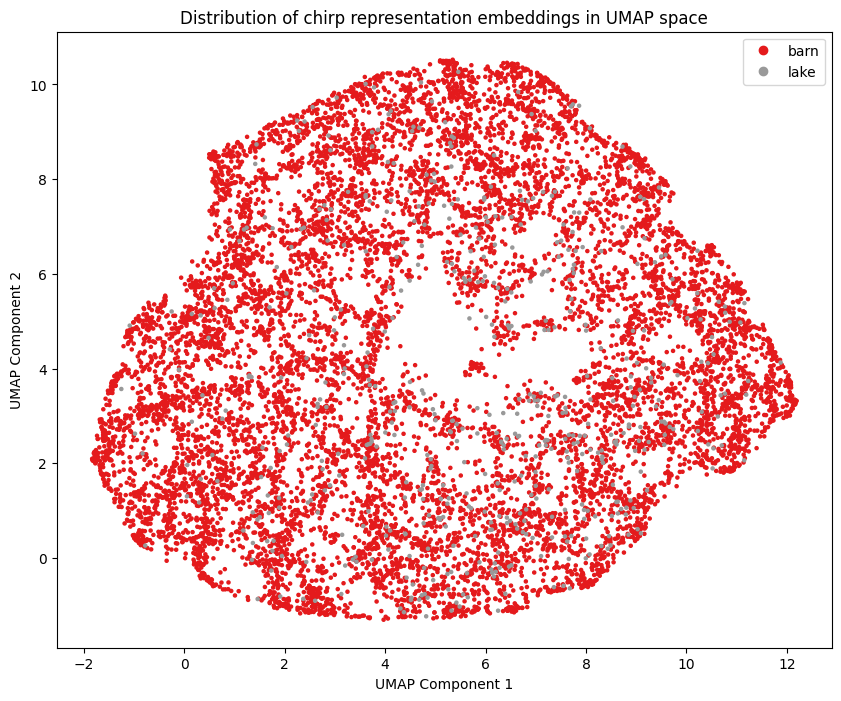

In [7]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(combined_chirp_attributes_embedded[:, 0], 
                      combined_chirp_attributes_embedded[:, 1], 
                      c=combined_chirp_attributes["original_df"], 
                      cmap="Set1", 
                      s=5,
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, ["barn", "lake"])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [8]:
idiom_boundaries_attributes

,0,1,original_df
0,2.0,11.0,1
1,49.0,54.0,1
2,62.0,70.0,1
3,95.0,99.0,1
4,111.0,115.0,1
...,...,...,...
637,382.0,386.0,2
638,437.0,443.0,2
639,462.0,466.0,2
640,467.0,472.0,2


In [9]:
# get the idiom chirp attributes
idiom_chirp_idxs = []
for idx, row in idiom_boundaries_attributes.iterrows():
    for i in range(int(row[0]), int(row[1]) + 1):
        idiom_chirp_idxs.append((idx, i, row["original_df"]))

idiom_chirp_attributes = pd.DataFrame()
for idiom_idx, chirp_idx, original_df in idiom_chirp_idxs:
    attributes = combined_chirp_attributes.loc[(combined_chirp_attributes["original_df"] == original_df) & 
                                                (combined_chirp_attributes["OriginalIndex"] == chirp_idx)]
    if idiom_chirp_attributes.empty:
        idiom_chirp_attributes = attributes
    else:
        idiom_chirp_attributes = pd.concat([idiom_chirp_attributes, attributes])
idiom_chirp_attributes.reset_index(inplace=True)
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,2,2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
1,3,3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
2,4,4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
3,5,5,1338.000015,81.000000,88.675825,45.164369,53.692662,54.726804,61.536750,28.691722,...,15579.253756,15225.152192,26.305368,20.552334,182.140376,159.267579,5.644597,16694.0,15.0,1
4,6,6,1257.999994,90.000000,79.066596,32.974939,49.437098,80.856611,63.246841,20.791700,...,9075.354376,19684.511002,18.863124,17.109394,152.684928,149.200427,27.468304,16694.0,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,11439,544,1238.999989,55.000000,103.007111,56.885528,58.730615,57.731113,74.702106,26.241414,...,11316.982123,11650.711411,28.783874,31.082635,223.935242,252.810892,8.119629,1089.0,9.0,2
4076,11440,545,1184.000002,53.000000,98.284760,44.270036,58.485972,82.147469,74.192283,37.339758,...,16615.629503,16091.092995,28.755010,31.217452,234.964736,271.874665,-6.012109,1089.0,8.0,2
4077,11441,546,1132.000007,166.000004,89.436597,43.714378,57.158957,65.008663,57.053220,66.057189,...,18380.929975,13654.596595,58.218397,49.417561,838.909005,687.387395,6.342850,1089.0,7.0,2
4078,11442,547,877.000000,162.000000,71.931755,26.541425,58.034384,49.148269,53.487984,69.734334,...,13868.277460,9406.794472,16.842018,10.441945,182.089148,129.617425,6.902197,1089.0,6.0,2


In [10]:
idiom_chirp_attributes_embedded = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
).fit_transform(idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy())

/home/ayc227/miniconda3/envs/bats310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0, 0.5, 'UMAP Component 2')

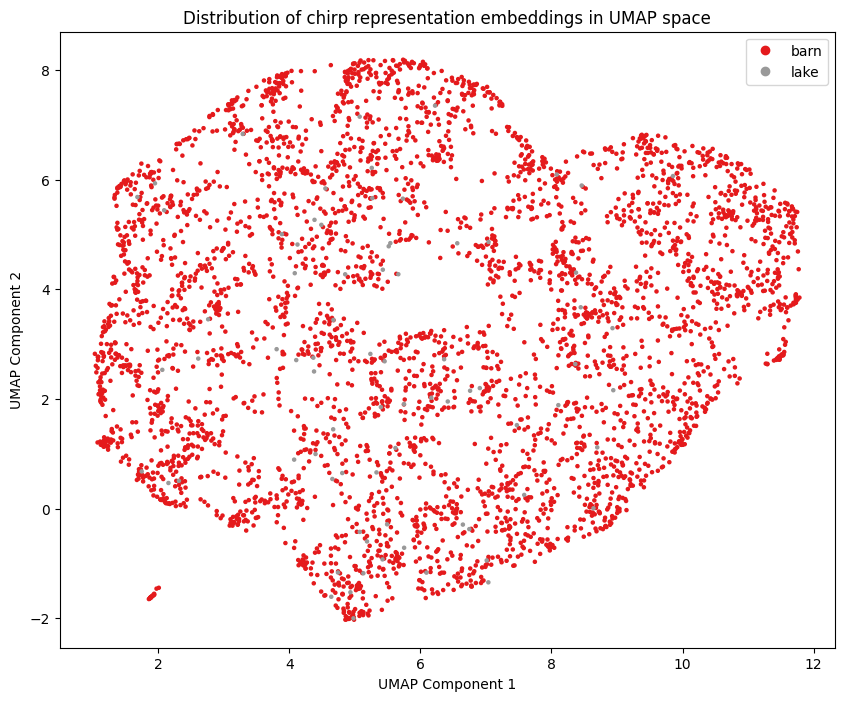

In [11]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(idiom_chirp_attributes_embedded[:, 0], 
                      idiom_chirp_attributes_embedded[:, 1], 
                      c=idiom_chirp_attributes["original_df"], 
                      cmap="Set1", 
                      s=5,
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
handles, labels = scatter.legend_elements()
plt.legend(handles, ["barn", "lake"])
plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2")
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

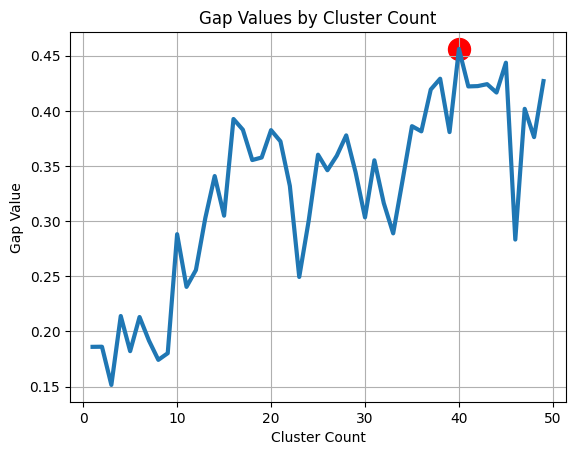

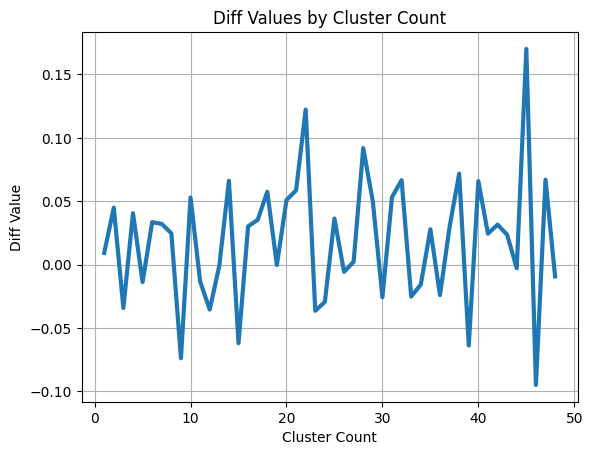

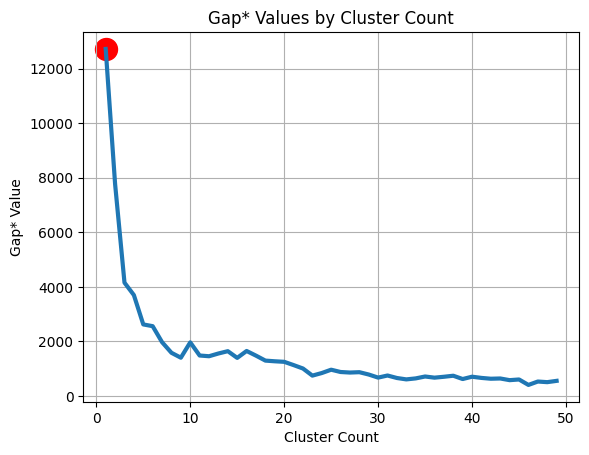

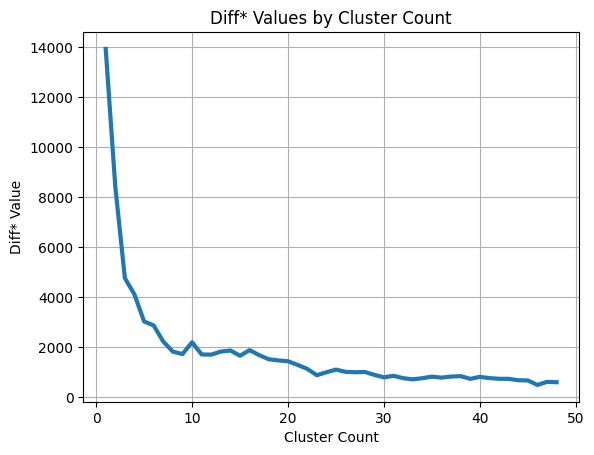

100%|██████████| 49/49 [00:14<00:00,  3.38it/s]


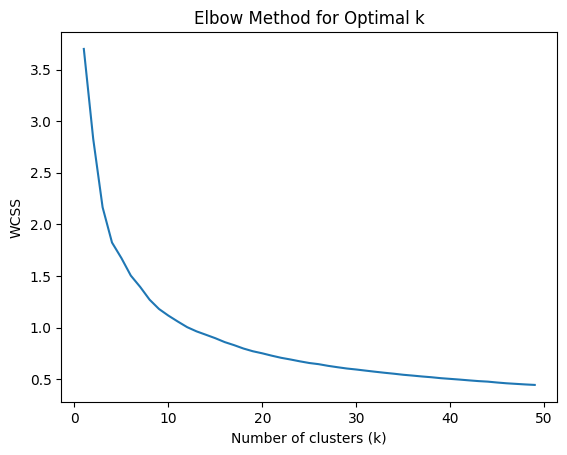

{'gap_statistic': 40, 'diff_statistic': 1, 'elbow_method': 9}

In [12]:
MIN_K = 1
MAX_K = 50

n_clusters = find_ideal_cluster_k(idiom_chirp_attributes_embedded, MIN_K, MAX_K)
n_clusters

In [13]:
clustering = "Agglomerative"
umap = True
NUM_CLUSTERS = n_clusters["elbow_method"]

cluster_data_input = idiom_chirp_attributes_embedded if umap else idiom_chirp_attributes.loc[:, 'PrecedingIntrvl':'AmpK@start'].to_numpy()
chirp_labels = cluster_chirps(cluster_data_input, clustering, umap, NUM_CLUSTERS)

chirp_labels

array([6, 5, 5, ..., 0, 5, 0])

In [14]:
idiom_chirp_attributes

,index,OriginalIndex,TimeInFile,PrecedingIntrvl,HiFreq,Bndwdth,FreqMaxPwr,PrcntMaxAmpDur,FreqKnee,PrcntKneeDur,...,Amp3rdQrtl,Amp4thQrtl,1st10kHzSlp,1st5to15kHzSlp,1st10kHzExp,1st5to15kHzExp,AmpK@start,file_id,chirp_idx,original_df
0,2,2,1680.000025,83.000000,82.795382,39.384269,53.916698,55.368983,60.247496,32.149732,...,19896.553411,17251.677170,17.881734,21.593664,134.551667,159.316855,6.834603,16694.0,18.0,1
1,3,3,1596.999944,90.000000,83.515950,40.841733,55.067086,47.408007,61.631393,26.460283,...,11501.507768,13995.540981,17.204441,17.644916,130.237594,135.986491,4.906056,16694.0,17.0,1
2,4,4,1506.999984,79.000000,87.488464,46.045368,57.271147,43.938016,61.581652,30.463689,...,13637.774716,14611.093873,29.915348,23.788136,205.131836,178.565429,2.358377,16694.0,16.0,1
3,5,5,1338.000015,81.000000,88.675825,45.164369,53.692662,54.726804,61.536750,28.691722,...,15579.253756,15225.152192,26.305368,20.552334,182.140376,159.267579,5.644597,16694.0,15.0,1
4,6,6,1257.999994,90.000000,79.066596,32.974939,49.437098,80.856611,63.246841,20.791700,...,9075.354376,19684.511002,18.863124,17.109394,152.684928,149.200427,27.468304,16694.0,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,11439,544,1238.999989,55.000000,103.007111,56.885528,58.730615,57.731113,74.702106,26.241414,...,11316.982123,11650.711411,28.783874,31.082635,223.935242,252.810892,8.119629,1089.0,9.0,2
4076,11440,545,1184.000002,53.000000,98.284760,44.270036,58.485972,82.147469,74.192283,37.339758,...,16615.629503,16091.092995,28.755010,31.217452,234.964736,271.874665,-6.012109,1089.0,8.0,2
4077,11441,546,1132.000007,166.000004,89.436597,43.714378,57.158957,65.008663,57.053220,66.057189,...,18380.929975,13654.596595,58.218397,49.417561,838.909005,687.387395,6.342850,1089.0,7.0,2
4078,11442,547,877.000000,162.000000,71.931755,26.541425,58.034384,49.148269,53.487984,69.734334,...,13868.277460,9406.794472,16.842018,10.441945,182.089148,129.617425,6.902197,1089.0,6.0,2


In [15]:
idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2].iloc[0].name

4003

In [16]:
import matplotlib 
from matplotlib.colors import ListedColormap

cmap1_colors = matplotlib.colormaps["Set1"](np.linspace(0, 1, 256))
cmap2_colors = cmap1_colors * 0.5
cmap2_colors[:, 3] = 1
cmap2_colors
cmap2 = ListedColormap(cmap2_colors, name="Set1dark")

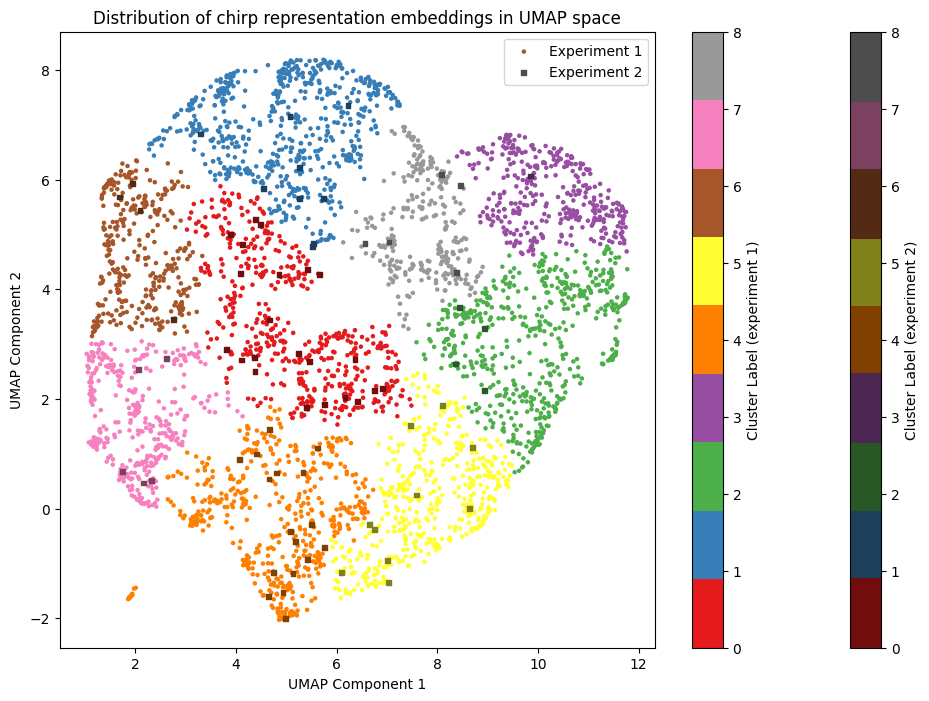

In [17]:
# plot the idiom chirps with their clusters, with the two experiments designated with different shapes
second_exp_first_row = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2].iloc[0].name

plt.figure(figsize=(12, 8))
scatter1 = plt.scatter(idiom_chirp_attributes_embedded[:second_exp_first_row, 0], 
                      idiom_chirp_attributes_embedded[:second_exp_first_row, 1], 
                      c=chirp_labels[:second_exp_first_row], 
                      cmap="Set1", 
                      s=5, 
                      vmin=min(chirp_labels), 
                      vmax=max(chirp_labels)
                      )
scatter2 = plt.scatter(idiom_chirp_attributes_embedded[second_exp_first_row:, 0], 
                      idiom_chirp_attributes_embedded[second_exp_first_row:, 1], 
                      c=chirp_labels[second_exp_first_row:], 
                      cmap=cmap2, 
                      s=12, 
                      marker="s",
                      vmin=min(chirp_labels), 
                      vmax=max(chirp_labels)
                      )
plt.title(f"Distribution of chirp representation embeddings in UMAP space")
# handles, labels = scatter1.legend_elements()
# plt.legend(handles, ["barn", "lake"])
plt.colorbar(scatter2, label="Cluster Label (experiment 2)")
plt.colorbar(scatter1, label="Cluster Label (experiment 1)")
plt.legend(["Experiment 1", "Experiment 2"])

plt.xlabel(f"{'UMAP' if umap else 'PCA'} Component 1")
plt.ylabel(f"{'UMAP' if umap else 'PCA'} Component 2");
# if not umap:
#     plt.xlim(-8800, -8000);
#     plt.ylim(-1400, -1000);

In [18]:
idiom_chirp_attributes['cluster_idx'] = chirp_labels
idiom_label_sequences = idiom_chirp_attributes.groupby(["file_id", "original_df"]).agg(list)["cluster_idx"].reset_index()
idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]

,file_id,original_df,cluster_idx
10,16694.0,1,"[6, 5, 5, 4, 7, 1, 7, 1, 3, 7]"
11,16698.0,1,"[3, 3, 3, 3, 2, 3]"
12,16699.0,1,"[4, 8, 4, 0, 1, 7, 5, 4, 1]"
13,16702.0,1,"[0, 7, 5, 3, 6]"
14,16703.0,1,"[3, 5, 3, 1, 3, 8, 4, 0]"
...,...,...,...
378,17496.0,1,"[5, 8, 4, 4, 4, 8, 1, 7, 1, 1, 1, 1]"
379,17499.0,1,"[1, 6, 1, 7, 7, 6, 1]"
380,17514.0,1,"[6, 2, 5, 7, 1, 5, 2, 3, 2, 3, 5, 1]"
381,17516.0,1,"[8, 2, 8, 4, 3, 2, 5]"


In [19]:
idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 1]['cluster_idx'].values

array([6, 5, 5, ..., 6, 0, 2])

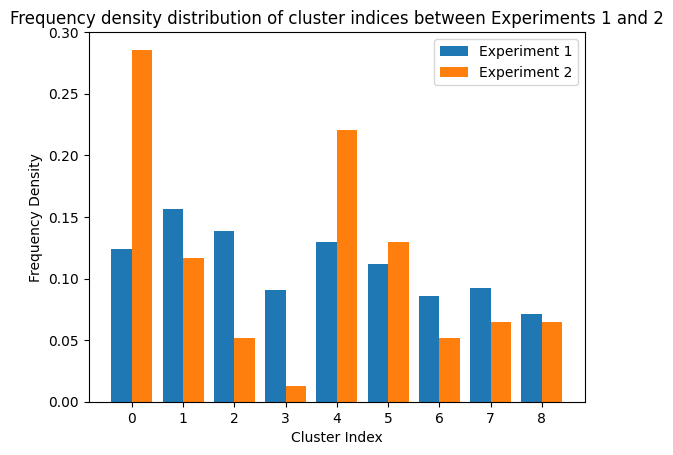

In [20]:
# plot a histogram of cluster indices across the two experiments
first_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 1]['cluster_idx'].values
second_exp_clusters = idiom_chirp_attributes.loc[idiom_chirp_attributes["original_df"] == 2]['cluster_idx'].values
plt.hist([first_exp_clusters, second_exp_clusters], 
         bins=(np.arange(min(chirp_labels), max(chirp_labels) + 2) - 0.5), 
         density=True,
        #  stacked=True,
         )
plt.xticks(range(min(chirp_labels), max(chirp_labels) + 1))
plt.title("Frequency density distribution of cluster indices between Experiments 1 and 2")
plt.xlabel("Cluster Index")
plt.ylabel("Frequency Density")
plt.legend(["Experiment 1", "Experiment 2"]);

In [30]:
LENGTH = 2
K_MOST_COMMON = 10
# find most common subsequences across both experiments
subseq_all = most_common_subsequences(idiom_label_sequences['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type="all", 
                         k=K_MOST_COMMON)
# find most common subsequences in only the first experiment
subseq_exp1 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 1]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type="all",
                         k=K_MOST_COMMON)
# find most common subsequences in only the second experiment
subseq_exp2 = most_common_subsequences(idiom_label_sequences.loc[idiom_label_sequences["original_df"] == 2]['cluster_idx'].values, 
                         LENGTH, 
                         subseq_type="all",
                         k=K_MOST_COMMON)
print(pd.DataFrame(subseq_all, columns=['Prefix', 'Count']))
print(pd.DataFrame(subseq_exp1, columns=['Prefix', 'Count']))
print(pd.DataFrame(subseq_exp2, columns=['Prefix', 'Count']))

   Prefix  Count
0  (1, 1)    115
1  (4, 4)     95
2  (2, 1)     91
3  (2, 2)     89
4  (1, 5)     70
5  (1, 0)     69
6  (1, 2)     67
7  (0, 0)     66
8  (0, 2)     66
9  (3, 2)     66
   Prefix  Count
0  (1, 1)    114
1  (4, 4)     92
2  (2, 1)     90
3  (2, 2)     89
4  (1, 5)     69
5  (1, 2)     67
6  (3, 2)     66
7  (1, 0)     66
8  (1, 4)     66
9  (0, 2)     64
   Prefix  Count
0  (0, 0)      6
1  (4, 0)      5
2  (0, 4)      5
3  (8, 4)      3
4  (4, 4)      3
5  (5, 0)      3
6  (1, 0)      3
7  (4, 1)      3
8  (0, 1)      2
9  (0, 5)      2
